In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# simple binary dataset
X = np.array([
    [1.0,1.0],
    [1.5,2.0],
    [2.0,1.5],
    [3.0,3.0],
    [3.5,2.5],
    [4.0,3.0],
])

y = np.array([0,0,0,1,1,1])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (6, 2)
y shape: (6,)


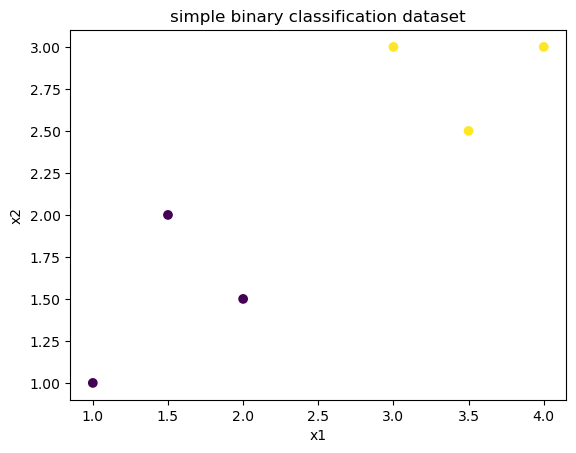

In [5]:
plt.scatter(X[:,0],X[:,1],c=y)
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('simple binary classification dataset')
plt.show()

### step 1 : Sigmoid function 

In [31]:
# Sigmoid function maps a raw score to a probability in the range [0,1]
def sigmoid(z):
    # Numerical stability is important to avoid overflow when computing exp(z)
    z = np.asarray(z, dtype=float)
    z_out = np.empty_like(z)
    
    # boolean masking separates negative and positive values to ensure numerical stability
    neg_mask = z < 0
    pos_mask = z >= 0

    z_out[neg_mask] = np.exp(z[neg_mask]) / (1 + np.exp(z[neg_mask]))
    z_out[pos_mask] = 1 / (1 + np.exp(-z[pos_mask]))
    
    return z_out                          

In [32]:
# Quick tests
test_vals = np.array([-1000, -5, -1, 0, 1, 5, 1000], dtype=float)
print('test_vals:', test_vals)
print('sigmoid(test_vals):', sigmoid(test_vals))

test_vals: [-1000.    -5.    -1.     0.     1.     5.  1000.]
sigmoid(test_vals): [0.         0.00669285 0.26894142 0.5        0.73105858 0.99330715
 1.        ]


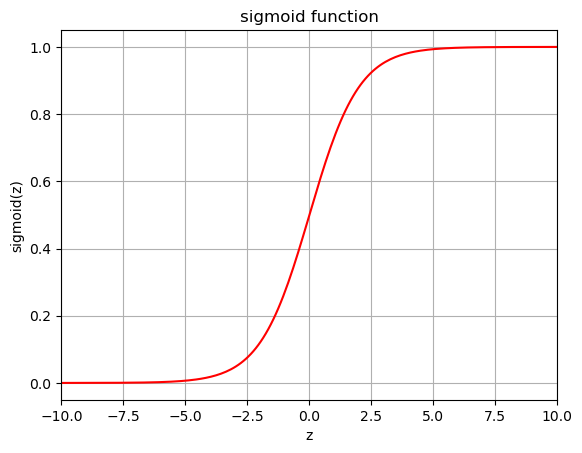

In [33]:
# visualize sigmoid curve
z_plot = np.linspace(-10, 10, 200)
plt.plot(z_plot, sigmoid(z_plot), 'r')
plt.xlabel('z')
plt.ylabel('sigmoid(z)')
plt.xlim([-10,10])
plt.title('sigmoid function')
plt.grid(True)
plt.show()

### Sigmoid Warm-up (Intuition only)

Before implementing logistic regression end-to-end, we first visualize the sigmoid function on a small synthetic input. 

This step is used only to build intuition about:
 - how raw scores(z) map to probabilities(p)
 - why 0.5 is used as the decision threshold

The dataset used in this section is **not** used for training or optimization. 
From the next section onward, we switch to a 2D dataset to implement logistic regression fully and visualize the decision boundary.

### Step 2 : Logistic hypothesis (Linear score)

In [35]:
# simple dataset
X = np.array([
    [1, 1],
    [2, 1],
    [2, 2],
    [3, 2],
], dtype = float)

y = np.array([0, 0, 1, 1])

In [36]:
# Initialize weights and bias 
w = np.array([0.5, -0.5])
b = 0.0

# compute linear scores
z = X @ w + b         # same as np.dot(X,w)

print("X\n:", X)
print("w:", w)
print("b:", b)
print("z:", z)

X
: [[1. 1.]
 [2. 1.]
 [2. 2.]
 [3. 2.]]
w: [ 0.5 -0.5]
b: 0.0
z: [0.  0.5 0.  0.5]


In [38]:
# Apply sigmoid to linear scores
p = sigmoid(z)

print("z (linear scores):", z)
print("p (predicted probabilities):", p)

z (linear scores): [0.  0.5 0.  0.5]
p (predicted probabilities): [0.5        0.62245933 0.5        0.62245933]


### Step 3 : Binary cross-entropy loss (log loss)

Binary cross entropy loss is the negative log likelihood of a Bernoulli distribution. The calculation of loss function is important because it quantifies the error using predicted probabilities assigning small penalty to confident correct predictions and imposing huge penalty to confident wrong predictions. This numeric penalty is necessary for learning because it provides the necessary direction to minimize the error during training. Without loss function thresholding the predicted probabilities directly only tells the final class label(0 or 1) but not how wrong or how confident the model is.

In [39]:
def binary_cross_entropy(y_true, p_pred):
    """
    y_true: shape(m,) target/labels with values 0 or 1
    p_pred: shape(m,) predicted probabilities between [0,1]
    """
    y_true = np.asarray(y_true, dtype=float)
    p_pred = np.asarray(p_pred, dtype=float)

    # numerical stability to avoid log(0) in predicted probabilities
    eps = 1e-10
    p_pred = np.clip(p_pred, eps, 1-eps)

    # loss per sample
    loss_sample = -(y_true * np.log(p_pred) + (1-y_true) * np.log(1-p_pred))

    # mean loss for across all the samples 
    loss_total = np.mean(loss_sample)

    return loss_total, loss_sample    

In [41]:
# Quick test
J, loss = binary_cross_entropy(y, p)
print("true labels:", y)
print("predicted probabilities:", p)
print("loss per sample:", loss)
print("mean loss:", J)

true labels: [0 0 1 1]
predicted probabilities: [0.5        0.62245933 0.5        0.62245933]
loss per sample: [0.69314718 0.97407698 0.69314718 0.47407698]
mean loss: 0.7086120823700259


### Step 4 : Gradients computation

The gradients quantify in terms of both direction and magnitude how the loss changes with respect to the model parameters weights(w) and bias(b).

This is achieved by using the signed error (p-y) for each sample:

 - negative when the model under-predicts the true class
 - positive when the model over-predicts

Weight gradients are computed as the average contribution of each feature scaled by this error, and bias gradient represent the average error across all the samples. 

In [54]:
def gradients_compute(X, y, w, b):
    """
    m - number of instances
    n - number of features
    X : (m,n)
    y : (m,)
    w : (n,)
    b : scalar
    """
    m = X.shape[0]

    # forward pass
    z = X @ w + b     # (m,)
    p = sigmoid(z)    # (m,)

    # error in prediction 
    dz = p - y        # (m,)

    # Calculation of gradients
    dw = (X.T @ dz) / m      # (n,)
    db = dz.mean()           # scalar

    return dw, db, z, p    

In [55]:
# check test
dw, db, z, p = gradients_compute(X, y, w, b)

print("Raw linear score, z:", z)
print("Predicted probabilites, p:", p)
print("Gradients for weights, dw:", dw)
print("Gradient for bias, db:", db)
print("Shapes -> X:", X.shape, "w:", w.shape, "dw:", dw.shape)

Raw linear score, z: [0.  0.5 0.  0.5]
Predicted probabilites, p: [0.5        0.62245933 0.5        0.62245933]
Gradients for weights, dw: [-0.09692584 -0.1581555 ]
Gradient for bias, db: 0.06122966560092727
Shapes -> X: (4, 2) w: (2,) dw: (2,)


### Step 5 : Parameter update (Gradient descent update)

Gradient descent is the step where we update the model parameters weights and bias in the direction that reduces loss given by:

 - w = w - learning_rate*weight_gradients
 - b = b - learning_rate*bias_gradient

Learning rate controls how big each parameter update step is.

In [70]:
# Single update step
def parameters_update(w, b, dw, db, lr):
    """
    Performs one gradient descent update
    """
    w = w - lr * dw
    b = b - lr * db
    return w,b

In [72]:
# Test one update 
lr = 0.1    # learning rate

print("Before update:")
print("w:", w)
print("b:", b)

w_new, b_new = parameters_update(w, b, dw, db, learning_rate)
print("\nAfter update:")
print("w:", w_new)
print("b:", b_new)

Before update:
w: [ 0.5 -0.5]
b: 0.0

After update:
w: [ 0.50969258 -0.48418445]
b: -0.006122966560092727


In [73]:
# Recompute loss after update
z_new = X @ w_new + b_new
p_new = sigmoid(z_new)
J_new,_ = binary_cross_entropy(y, p_new)

print("Old loss:", J)
print("New loss:", J_new)

Old loss: 0.7086120823700259
New loss: 0.7049830230163309


### Step 6 : Training loop (batch gradient descent)

The training loop is the iterative process to the find the optimal model parameters (weights and bias) through the process of : 

 - forward pass (raw scores and predicted probabilities)
 - loss calculation (binary cross entropy)
 - gradients (dw,db)
 - parameter update (gradient descent)

In [85]:
def train_logistic_regression(X, y, lr, num_iterations):
    m, n = X.shape
    w = np.zeros(n)
    b = 0.0

    loss_history = []

    for i in range(num_iterations):
        # forward pass(z & p) and gradients calculation(dw & db)
        dw, db, z, p = gradients_compute(X, y, w, b)
        
        # loss computed before update (used old parameters)
        J,_ = binary_cross_entropy(y,p)
        loss_history.append(J)
        
        # update parameters
        w = w - lr*dw
        b = b - lr*db      
        
    return w, b, loss_history      

In [86]:
w_final, b_final, loss = train_logistic_regression(X, y, lr=0.1, num_iterations=1000)
print("weights:",w_final)
print("Bias:",b_final)
print("final Loss:", loss[-1])

weights: [0.17562198 3.71376216]
Bias: -5.651997330850467
final Loss: 0.1382334874440225


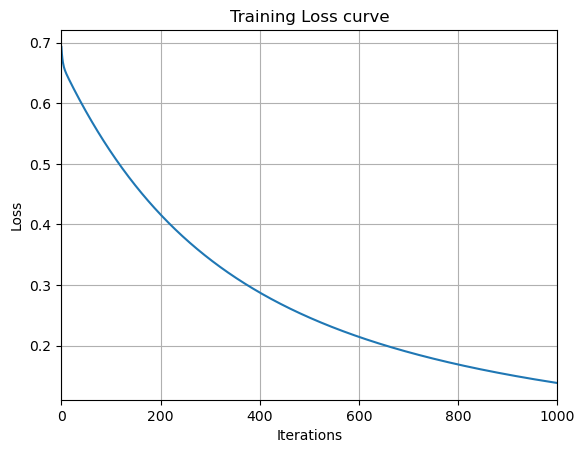

In [87]:
# Plot loss curve
plt.plot(loss)
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.xlim([0,1000])
plt.title("Training Loss curve")
plt.grid(True)
plt.show()

### Step 7 : Prediction & Decision Boundary (Binary Logistic)

Prediction is the step where model predicts each instance by converting the predicted probabilities into respective class labels based on the threshold.

 - p = P(y=1 | x) from sigmoid
 - Predict 1 if p ≥ threshold else 0 (default threshold = 0.5)

#### 7.1. Prediction functions

In [95]:
# calculation of probabilties using the final model parameters
def predict_proba(X, w, b):
    """
    X : (m,n)
    w : (n,)
    b : scalar
    """
    z = X @ w + b
    p = sigmoid(z)
    return p

# model prediction of class labels
def predict_class(X, w, b, threshold=0.5):
    """
    p : (m,)
    y_pred : (m,)
    """
    p = predict_proba(X, w, b)
    y_pred = (p>=threshold).astype(int)
    return y_pred

In [92]:
# check test
y_pred = predict_class(X, w_final, b_final)
accuracy = (y_pred == y).mean()
print("Accuracy:", accuracy)

Accuracy: 1.0


#### 7.2. Visualization of Decision boundary / Regions

Decision boundary is the set of points where the model is indifferent: p = 0.5, equivalently z = 0, ie wᵀx + b = 0.

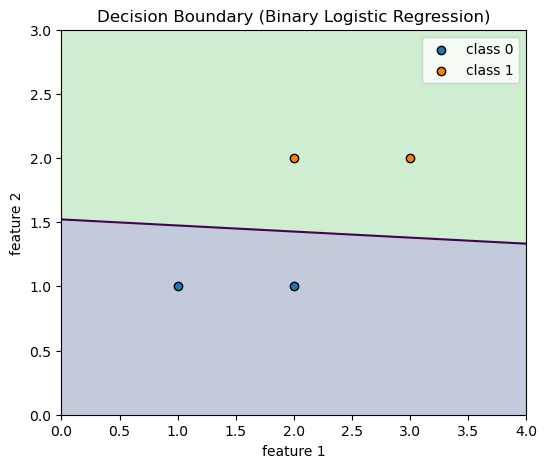

In [100]:
# Create a grid over feature space
x0_min, x0_max = X[:,0].min() - 1, X[:,0].max() + 1
x1_min, x1_max = X[:,1].min() - 1, X[:,1].max() + 1

grid_res = 300
x0, x1 = np.meshgrid(
    np.linspace(x0_min, x0_max, grid_res),
    np.linspace(x1_min, x1_max, grid_res)
)
grid = np.c_[x0.ravel(), x1.ravel()]

# predict probabilities on the grid 
P = predict_proba(grid, w_final, b_final).reshape(x0.shape)

# plot decision regions + boundary
plt.figure(figsize=(6,5))

# decision regions
plt.contourf(x0, x1, P, levels=[0,0.5,1], alpha=0.3)

# boundary line at p=0.5
plt.contour(x0, x1, P, levels=[0.5])

# training points
plt.scatter(X[y==0,0], X[y==0,1], label='class 0', edgecolor='k')
plt.scatter(X[y==1,0], X[y==1,1], label='class 1', edgecolor='k')

plt.xlabel("feature 1")
plt.ylabel("feature 2")
plt.title("Decision Boundary (Binary Logistic Regression)")
plt.legend()
plt.show()